# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [ ]:
import sys
sys.path.append('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks')
import functions  # First import
import importlib
importlib.reload(functions)  # Reload to reflect changes
from functions import *  # Now import updated functions

#add_custom_fonts(loc=".myfonts")
# import subprocess
# from shadow.plot import *
# from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

# Read data

In [ ]:
np.random.seed(1002)
random.seed(0)

df_filtered_quantile = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/filtered_quantile.pkl')
ALL = df_filtered_quantile.copy(deep = True)
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] >= 90) & (ALL['NOx content in the raw gas (preheater outlet)'] <= 1000)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
##################################################################### remove nestor's unreliable params
X.drop(['Exit temperature from each preheater cyclone (Stage 5)',
'Flue gas outlet temperature (calciner outlet)',
'Flue gas O2 content (calciner outlet)',
'Clinker outlet temperature'], axis = 1, inplace = True)
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]
print(f'Datapoints test-train split = {len(X)}')
y = y2
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

Datapoints test-train split = 277079


In [4]:
len(ALL)

277079

# All model training (NOx)

### SVR works best

In [3]:
titles = ['Linear regression', 'Lasso', 'Ridge', 'Elastic net', 'Random forest', 'XGBoost', 'SVR', 'GPR', 'NN']

# LR

In [4]:
train_scores = []
val_scores = []
test_scores = []

LinearRegression()

Avg Training:  R^2 = 0.26, MAE = 34.89, MAPE = 11.59%
Avg Val:  R^2 = 0.26, MAE = 34.9, MAPE = 11.6%
Test 0.26 34.97 11.63


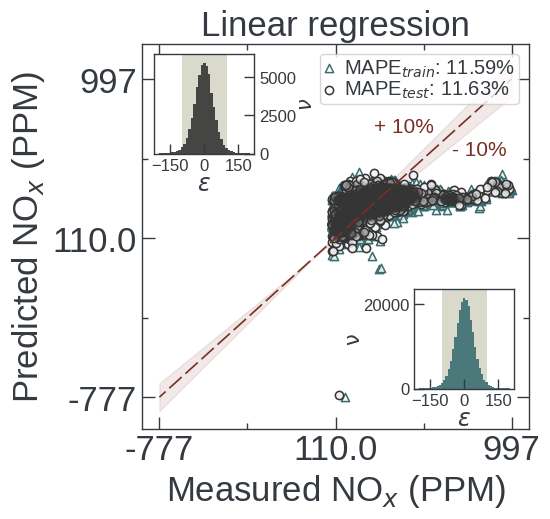

In [8]:
best_regressor = LinearRegression()
best_regressor.fit(X_train, y_train)

avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[0]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[0],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Lasso

In [5]:
random_search.best_params_

{'alpha': 0.001}

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=  16.1s
[CV] END .......................................alpha=0.0001; total time=  11.8s
[CV] END ........................................alpha=0.001; total time=   9.5s
[CV] END ..........................................alpha=0.1; total time=   8.0s
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 56.6803 s
System CPU time  : 0.2827 s
Total CPU time   : 56.9629 s
Wall clock time  : 57.1680 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.55%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32


{'alpha': 0.001}

Avg Training:  R^2 = 0.26, MAE = 34.89, MAPE = 11.59%
Avg Val:  R^2 = 0.26, MAE = 34.9, MAPE = 11.6%
Test 0.26 34.97 11.63


X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names


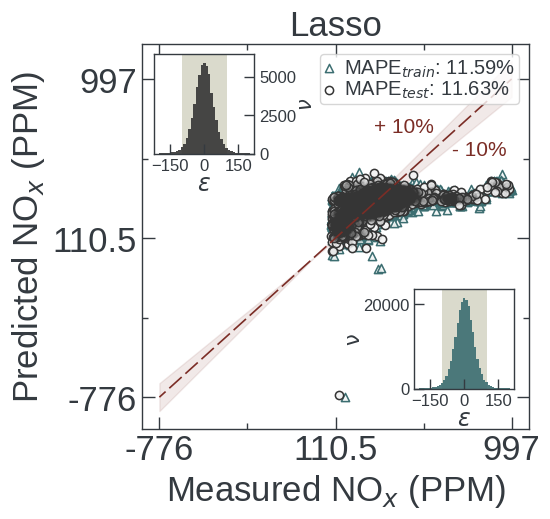

In [9]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Lasso()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
end_profiling(save_path = None, note = None)
random_search.best_params_

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
# parity plot
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[1]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[1],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Ridge

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.1s
[CV] END .......................................alpha=0.0001; total time=   0.1s
[CV] END ........................................alpha=0.001; total time=   0.1s
[CV] END ..........................................alpha=0.1; total time=   0.1s


{'alpha': 0.1}

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.5142 s
System CPU time  : 0.1440 s
Total CPU time   : 0.6582 s
Wall clock time  : 1.0705 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.78%
Max CPU usage    : 1.55%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.26, MAE = 34.89, MAPE = 11.59%
Avg Val:  R^2 = 0.26, MAE = 34.9, MAPE = 11.6%
Test 0.26 34.97 11.63


X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names


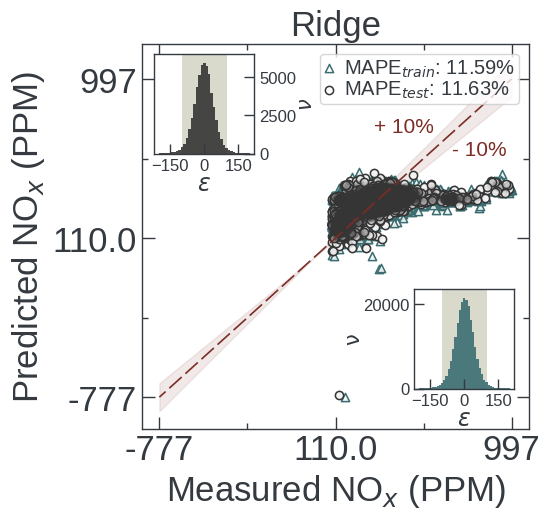

In [10]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Ridge()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
# parity plot
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[2]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[2],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Elastic net

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.381e+05, tolerance: 5.614e+04


[CV] END ........................................alpha=1e-05; total time=  16.5s
[CV] END .......................................alpha=0.0001; total time=  15.1s
[CV] END ........................................alpha=0.001; total time=  10.0s
[CV] END ..........................................alpha=0.1; total time=   4.8s


{'alpha': 0.001}

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 60.2492 s
System CPU time  : 0.2159 s
Total CPU time   : 60.4651 s
Wall clock time  : 60.6767 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.55%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.26, MAE = 34.89, MAPE = 11.59%
Avg Val:  R^2 = 0.26, MAE = 34.9, MAPE = 11.6%
Test 0.26 34.97 11.63


X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names


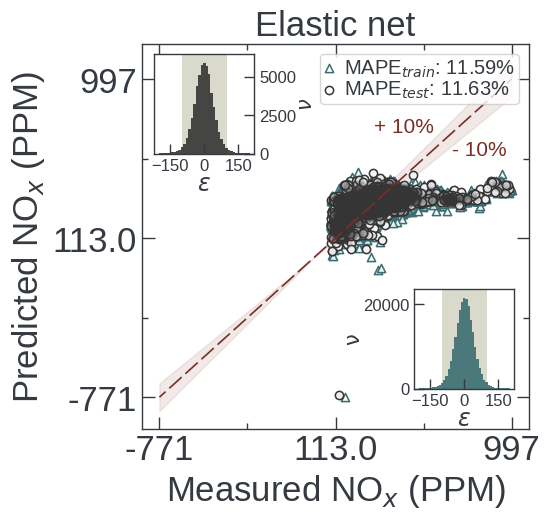

In [11]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = ElasticNet()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
iterations = 4
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
# parity plot
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[3]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[3],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Random forest

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
hyperparameter_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [12, 16, 20, 24, None],        # None = grow until pure
    "min_samples_split": [2, 4, 8, 16, 32],
    "min_samples_leaf": [1, 2, 4, 8, 12, 16],
    "max_features": [0.3, 0.4, 0.5, 0.6, "sqrt", "log2"],
    "ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005],
    "bootstrap": [True, False]
}
iterations =100
end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant1/RF_NOx_RanSearchCV.txt',
              note = 'RandomSearchCV for plant 1 Rf nox')
save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/RF_nox_best.pkl')

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant1/nox_RF.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
# parity plot
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[4]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[4],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 0.96, MAE = 8.28, MAPE = 2.66%
Avg Val:  R^2 = 0.78, MAE = 20.14, MAPE = 6.46%
Test 0.82 18.7 5.99


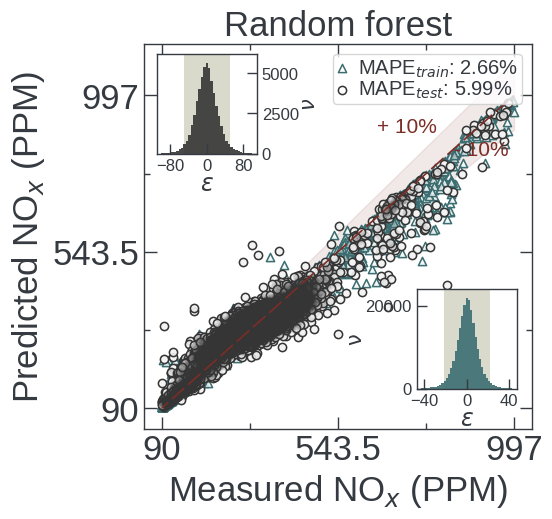

In [13]:
# manually tuned model
# bootstrap  = True, random_state=42, n_jobs=-1, 
# n_estimators = 1500,      
# max_depth = 40,           
# min_samples_split = 2,      
# min_samples_leaf = 2,       
# max_features = 0.8,       
# ccp_alpha = 0
np.random.seed(1002)
random.seed(0)
best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/RF_nox_best.pkl')
# train_test_score(best_regressor, X_train, X_test, y_train, y_test)
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[4]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[4],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

In [ ]:
best_regressor

RandomForestRegressor(ccp_alpha=0, max_depth=40, max_features=0.8,
                      min_samples_leaf=2, n_estimators=1500, n_jobs=-1,
                      random_state=42)

# XGboost

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# regressor = XGBRegressor(random_state=42, tree_method='gpu_hist', n_jobs=-1)
# hyperparameter_grid = {
#     "n_estimators": [200, 400, 600, 800],            # more trees but slower learning
#     "max_depth": [3, 4, 5, 6, 7],                   # shallower trees → less overfitting
#     "min_child_weight": [5, 7, 9, 11],               # larger = less complex splits
#     "subsample": [0.6, 0.7, 0.8, 0.9],               # row sampling
#     "colsample_bytree": [0.6, 0.7, 0.8, 0.9],        # feature sampling
#     "learning_rate": [0.01, 0.02, 0.03, 0.05],       # slower learning → needs more trees
#     "reg_lambda": [5, 7, 9, 11],                     # L2 regularization
#     "reg_alpha": [3, 5, 7, 9]                        # L1 regularization
# }
# iterations =100
# best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
#                                                        iterations = iterations, verbose= 2)
# random_search.best_params_
# end_profiling(save_path = None, note = None)

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = 'palnt2 CO XGBoost',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/XGboost.txt')
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
# # parity plot
# test_results = parity_train_test(best_regressor, titles[5],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)

Avg Training:  R^2 = 0.97, MAE = 7.43, MAPE = 2.38%
Avg Val:  R^2 = 0.81, MAE = 18.97, MAPE = 6.06%
Test 0.84 17.85 5.69


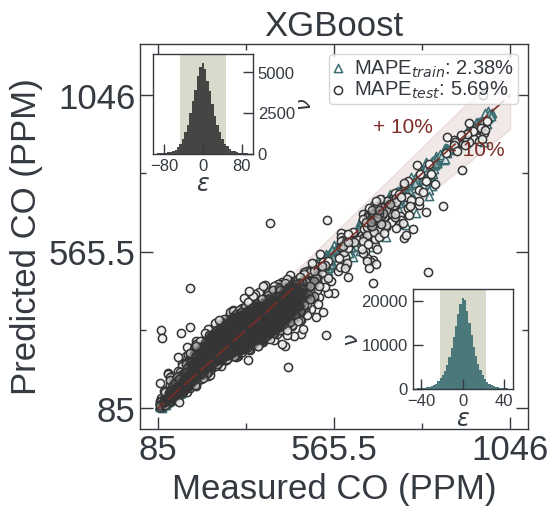

In [ ]:
# manually tuned model

# subsample = 0.9,              
# reg_lambda = 1,        
# reg_alpha = 1,         
# n_estimators = 1600,   
# min_child_weight = 6,  
# max_depth = 11,          
# learning_rate = 0.025, 
# colsample_bytree = 0.8,  
# random_state = 42,  
# tree_method = 'gpu_hist',  
# n_jobs = -1  

np.random.seed(1002)
random.seed(0)
best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_1_nox.pkl')
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[5]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[5],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Best Model stats

In [5]:
start_profiling() 

model_nox = XGBRegressor(
subsample = 0.9,              
reg_lambda = 1,        
reg_alpha = 1,         
n_estimators = 1600,   
min_child_weight = 6,  
max_depth = 11,          
learning_rate = 0.025, 
colsample_bytree = 0.8,  
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
train_test_score(model_nox, X_train, X_test, y_train, y_test)


end_profiling()

model_size('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_1_nox.pkl')

GPU 0: Utilization: 0%, Memory Used: 588 MB / 12282 MB
Training 0.96 8.3 2.65
Test 0.84 17.85 5.69
GPU 0: Utilization: 0%, Memory Used: 588 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 588 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 588 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 76.6240 s
System CPU time  : 0.5199 s
Total CPU time   : 77.1439 s
Wall clock time  : 77.2167 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.55%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32
Model size: 79.87 MB


# SVR

In [ ]:
# np.random.seed(1002)
# random.seed(0)
# start_profiling() 

# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= SVR(),
#         transformer=StandardScaler()))
# ])
# hyperparameter_grid = {
#     "kernel":  ["rbf", "poly", "sigmoid"],
#     "C":       [0.1, 1, 10, 50, 100, 200, 500],
#     "epsilon": [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
#     "gamma":   ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1],
#     "degree":  [2, 3, 4],          
#     "coef0":   [0.0, 0.1, 0.5, 1.0],
#     "tol":     [1e-4, 1e-3, 1e-2],
#     "shrinking": [True, False]
# }

# iterations = 200
# best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
#                                                        iterations = iterations, verbose= 1)
# random_search.best_params_
# end_profiling(save_path = None,
#               note = 'RandomSearchCV for plant 4 SVR')

# # save_model(best_regressor,
# #            model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/svr_best.pkl') # =None if not want to save

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/svr.txt")
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
# # parity plot
# test_results = parity_train_test(best_regressor, titles[6],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)

In [ ]:
# # Iteration 40
# regressor = SVR(tol= 0.0001, shrinking= False, kernel= 'rbf', gamma= 0.001, epsilon= 0.2, degree= 3, coef0= 0.5, C= 50)
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= regressor,
#         transformer=StandardScaler()))
# ])
# pipeline.fit(X_train, y_train)
# avg_train_results, _ = k_fold_scores(pipeline, X_train, y_train)
# test_results = parity_train_test(pipeline, titles[6],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)

# GPR

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= GaussianProcessRegressor(random_state=3),
#         transformer=StandardScaler()))
# ])
# hyperparameter_grid = {
#     "kernel": (
#         # Matern + WhiteKernel
#         [
#             ConstantKernel(1.0, (1e-3, 1e3)) *
#             Matern(length_scale=ls, nu=nu) +
#             WhiteKernel(noise_level=noise)
#             for ls in [0.1, 0.5, 1, 2, 5, 10]
#             for nu in [0.5, 1.5, 2.5]
#             for noise in [1e-5, 1e-3, 1e-1, 1]
#         ]
#         +
#         # RBF + WhiteKernel
#         [
#             ConstantKernel(1.0, (1e-3, 1e3)) *
#             RBF(length_scale=ls) +
#             WhiteKernel(noise_level=noise)
#             for ls in [0.1, 0.5, 1, 2, 5, 10]
#             for noise in [1e-5, 1e-3, 1e-1, 1]
#         ]
#         +
#         # RationalQuadratic + WhiteKernel
#         [
#             ConstantKernel(1.0, (1e-3, 1e3)) *
#             RationalQuadratic(length_scale=ls, alpha=alpha) +
#             WhiteKernel(noise_level=noise)
#             for ls in [0.1, 0.5, 1, 2, 5, 10]
#             for alpha in [0.1, 0.5, 1, 2]
#             for noise in [1e-5, 1e-3, 1e-1, 1]
#         ]
#     ),
#     "alpha": [1e-10, 1e-5, 1e-3, 1e-2, 1e-1, 1],
#     "normalize_y": [True, False],
# }

# iterations =200
# best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
#                                                        iterations = iterations, verbose= 1)
# random_search.best_params_
# end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant2/gpr_rand_SearchCV.txt',
#               note = 'RandomSearchCV for plant 2 gpr')

# save_model(best_regressor,
#            model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/gpr_best.pkl')

# # save Randomsearch results
# log_search_space(random_search.cv_results_ , file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/gpr.txt")
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
# # parity plot
# test_results = parity_train_test(best_regressor, titles[7],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test, avg_train_results, y, fig_path = fig_path)

In [ ]:
# # Iteration 
# np.random.seed(1002)
# random.seed(0)

# regressor = GaussianProcessRegressor(random_state = 3,
# normalize_y= True, kernel=1**2 * RationalQuadratic(alpha=2, length_scale=5) + WhiteKernel(noise_level=0.1), alpha = 1)
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= regressor,
#         transformer=StandardScaler()))
# ])
# pipeline.fit(X_train, y_train)
# avg_train_results, _ = k_fold_scores(pipeline, X_train, y_train)
# test_results = parity_train_test(pipeline, titles[7],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test, avg_train_results, y, fig_path = fig_path)

# NN

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= MLPRegressor(),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    'hidden_layer_sizes': [
        (64,), (128,), (256,),          # Single layer
        (64, 32), (128, 64), (256, 128), # Two layers
        (128, 64, 32), (64, 32, 16)      # Three layers (only for more data)
    ],
    'activation': ['relu'],
    'learning_rate_init': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'batch_size': [16, 32, 64, 128],
    'solver': ['adam'],  # 'lbfgs' works better for small datasets, 'adam' for large
    'early_stopping': [True],  # Keep fixed if you're using validation
    'n_iter_no_change': [20],
    'validation_fraction': [0.2],
    'max_iter': [500],
    'random_state': [42], 
    'verbose': [False]
}
iterations =100
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train,  # ravel for NN
                                                       iterations = iterations, verbose= 1)

random_search.best_params_
end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant1/NN_nox_rand_SearchCV.txt',
              note = 'RandomSearchCV for plant 1 nox nn')
save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_nox_best.pkl')

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant1/nox_nn.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
# parity plot
test_results = parity_train_test(best_regressor, titles[8],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)

In [ ]:
# manually tuned model
np.random.seed(1002)
random.seed(0)
# early_stopping = True ,             
# n_iter_no_change = 20,
# random_state = 42,
# activation = 'relu',                  
# solver = 'adam',                    
# max_iter = 200, 
# verbose = True,

# hidden_layer_sizes = (64,32, 16),  
# learning_rate_init = 0.0001 ,          
# batch_size = 32,                    
# alpha = 0.0001 

best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_nox_best.pkl')
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
test_results = parity_train_test(best_regressor, titles[8],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results, y, fig_path = fig_path)

In [ ]:
best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_nox_best.pkl')
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[8]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[8],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,[0.67,25.64,8.27], y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

### Train, val and test scores

In [ ]:
train_scores.insert(6, (np.NaN,np.NaN,np.NaN))
train_scores.insert(7, (np.NaN,np.NaN,np.NaN))
val_scores.insert(6, (np.NaN,np.NaN,np.NaN))
val_scores.insert(7, (np.NaN,np.NaN,np.NaN))
test_scores.insert(6, (np.NaN,np.NaN,np.NaN))
test_scores.insert(7, (np.NaN,np.NaN,np.NaN))

In [6]:
train_sc = [(0.26, 34.89, 11.59),
 (0.26, 34.89, 11.59),
 (0.26, 34.89, 11.59),
 (0.26, 34.89, 11.59),
 (0.96, 8.28, 2.66),
 (0.97, 7.43, 2.38),
 (np.NaN,np.NaN,np.NaN), 
(np.NaN,np.NaN,np.NaN),
 (0.97, 7.43, 2.38)]

val_sc = [(0.26,34.9,11.6),
 (0.26,34.9,11.6),
 ( 0.26,34.9,11.6),
 (0.26,34.9, 11.6),
 (0.78, 20.14, 6.46),
 ( 0.81, 18.97, 6.06),
 (np.NaN,np.NaN,np.NaN), 
(np.NaN,np.NaN,np.NaN),
 ( 0.64, 26.87, 8.66)]

test_sc = [(0.26, 34.97, 11.63),
 (0.26, 34.97, 11.63),
 (0.26, 34.97, 11.63),
 (0.26, 34.97, 11.63),
 (0.82, 18.7, 5.99),
 (0.84, 17.85, 5.69),
 (np.NaN,np.NaN,np.NaN), 
(np.NaN,np.NaN,np.NaN),
 (0.65, 26.53, 8.56)]

# with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_train_nox.pkl", "wb") as f:  
#     pickle.dump(train_sc, f)
    
# with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_val_nox.pkl", "wb") as f:  
#     pickle.dump(val_sc, f)
    
# with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_test_nox.pkl", "wb") as f:  
#     pickle.dump(test_sc, f)

### parity plots

LinearRegression()

Test 0.26 34.97 11.63


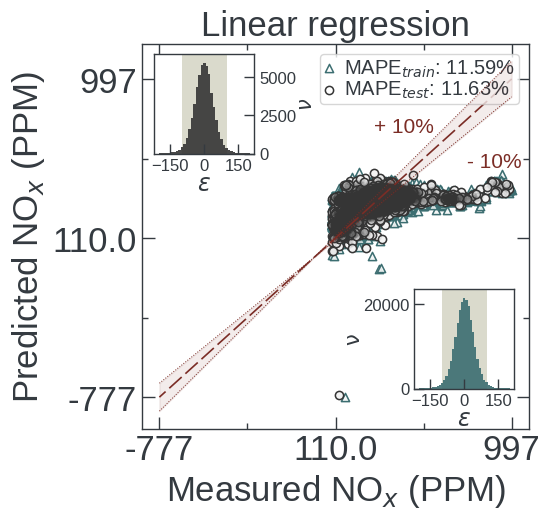

Lasso(alpha=0.001)

Test 0.26 34.97 11.63


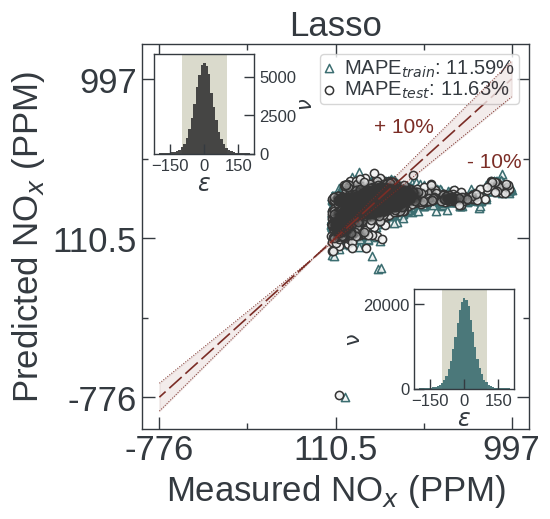

Ridge(alpha=0.1)

Test 0.26 34.97 11.63


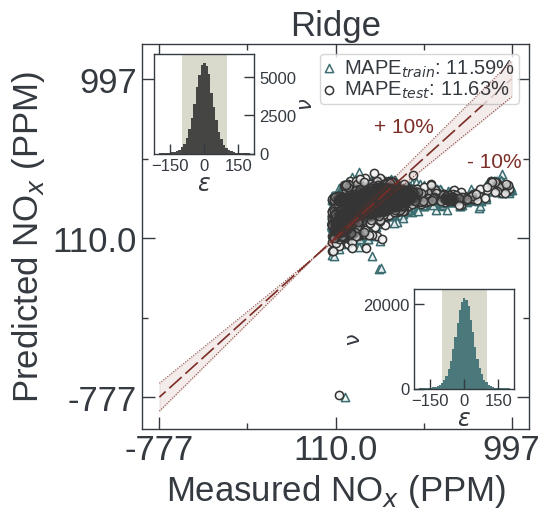

ElasticNet(alpha=0.001)

Test 0.26 34.97 11.63


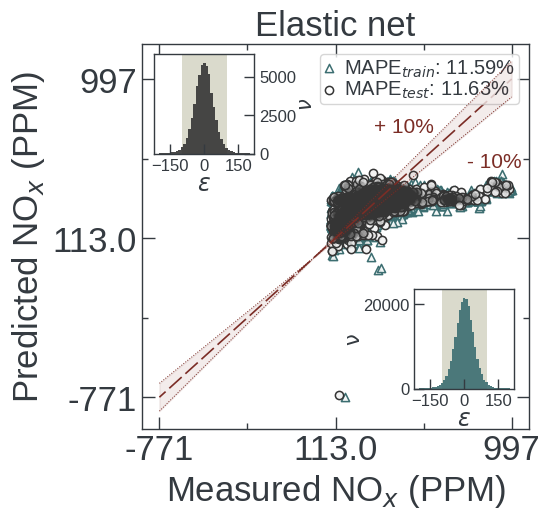

Test 0.82 18.7 5.99


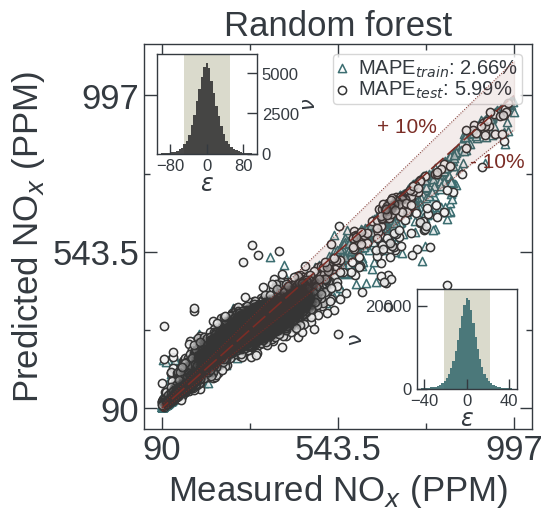

Test 0.84 17.85 5.69


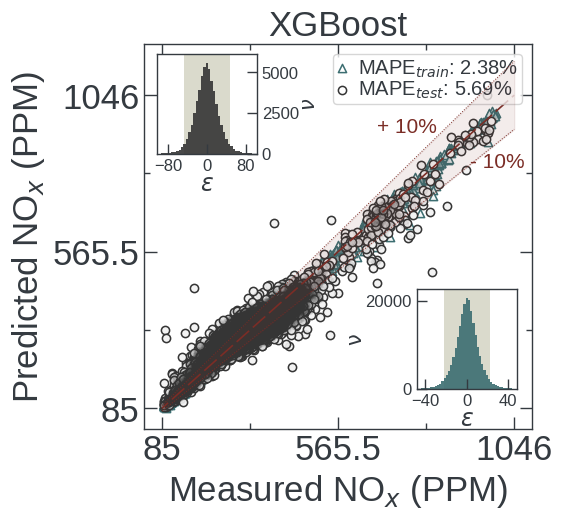

Test 0.65 26.53 8.56


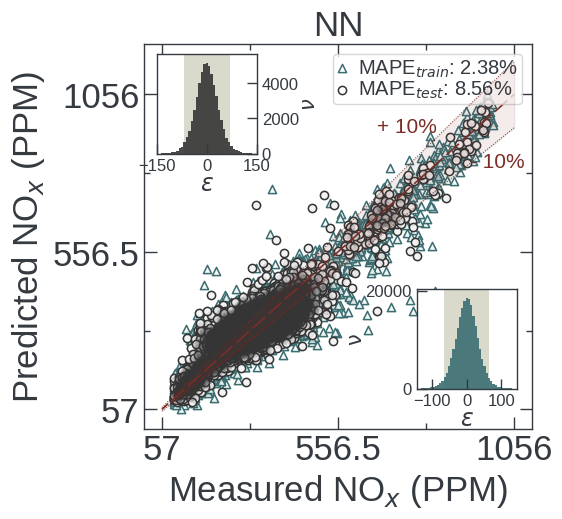

In [7]:
np.random.seed(1002)
random.seed(0)
best_regressor = LinearRegression()
best_regressor.fit(X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[0]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[0],'NO$_{x}$ (PPM)', X_train, X_test, y_train,y_test, list(train_sc[0]), y, fig_path = fig_path)


best_regressor = Lasso(alpha = 0.001)
best_regressor.fit(X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[1]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[1],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,list(train_sc[1]), y, fig_path = fig_path)

best_regressor = Ridge(alpha = 0.1)
best_regressor.fit(X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[2]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[2],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,list(train_sc[2]), y, fig_path = fig_path)

best_regressor = ElasticNet(alpha = 0.001)
best_regressor.fit(X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[3]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[3],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,list(train_sc[3]), y, fig_path = fig_path)

best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/RF_nox_best.pkl')
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[4]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[4],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,list(train_sc[4]), y, fig_path = fig_path)

best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_1_nox.pkl')
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[5]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[5],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,list(train_sc[5]), y, fig_path = fig_path)

best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_nox_best.pkl')
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/nox/{titles[8]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[8],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,list(train_sc[8]), y, fig_path = fig_path)